<a href="https://colab.research.google.com/github/ps-research/The-Language-of-AI-Liability/blob/main/Deontic_Modal_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 2 — Technique 1: Deontic Modal Analysis
ACL SRW 2026: The Language of AI Liability

Produces:
  Figure 1: Deontic modal density heatmap (counts per 100 sentences)
  Figure 2: Proportional deontic composition (stacked horizontal bar)
  Exports: 1200 DPI PDFs

In [ ]:
# ── Cell 1: Setup and load ──

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/ACL SRW TEXTS")
OUTPUT_DIR = BASE_DIR / "processed"
FIGURE_DIR = BASE_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

with open(OUTPUT_DIR / "preprocessed_corpus.json", "r", encoding="utf-8") as f:
    results = json.load(f)

print(f"Loaded {len(results)} laws")

# Consistent display order: group by jurisdiction/type
LAW_ORDER = [
    "eu_ai_act", "china_genai", "south_korea",
    "ca_sb1047", "ca_sb53", "ca_sb942", "ca_ab2013",
    "co_sb205", "tx_traiga", "il_hb3773",
]

LAW_LABELS = {
    "eu_ai_act":   "EU AI Act",
    "china_genai":  "China GenAI Measures",
    "south_korea":  "South Korea AI Basic Act",
    "ca_sb1047":    "CA SB 1047 (vetoed)",
    "ca_sb53":      "CA SB 53",
    "ca_sb942":     "CA SB 942",
    "ca_ab2013":    "CA AB 2013",
    "co_sb205":     "CO SB 205",
    "tx_traiga":    "TX TRAIGA",
    "il_hb3773":    "IL HB 3773",
}

CATEGORIES = ["HARD_OBLIGATION", "SOFT_OBLIGATION", "PERMISSION", "PROHIBITION"]
CAT_LABELS = ["Hard\nObligation", "Soft\nObligation", "Permission", "Prohibition"]

# Color palette — professional, colorblind-accessible
CAT_COLORS = {
    "HARD_OBLIGATION": "#2166ac",  # strong blue
    "SOFT_OBLIGATION": "#92c5de",  # light blue
    "PERMISSION":      "#f4a582",  # warm salmon
    "PROHIBITION":     "#b2182b",  # deep red
}

Loaded 10 laws


In [ ]:
# ── Cell 2: Build data matrices ──

# Raw counts
raw_counts = {}
total_sents = {}
for law_id in LAW_ORDER:
    r = results[law_id]
    total_sents[law_id] = r["stats"]["total_sentences"]
    raw_counts[law_id] = {
        cat: r["stats"]["deontic_counts"].get(cat, 0) for cat in CATEGORIES
    }

# Density: counts per 100 sentences
density_df = pd.DataFrame(
    {cat: {law_id: (raw_counts[law_id][cat] / total_sents[law_id]) * 100
           for law_id in LAW_ORDER}
     for cat in CATEGORIES}
)
density_df = density_df.loc[LAW_ORDER]

# Proportional: percentage of total deontic modals per law
proportion_df = pd.DataFrame(raw_counts).T
proportion_df = proportion_df.loc[LAW_ORDER]
row_totals = proportion_df.sum(axis=1)
proportion_pct = proportion_df.div(row_totals, axis=0) * 100
proportion_pct = proportion_pct.fillna(0)

print("Density (per 100 sentences):")
print(density_df.round(1).to_string())
print(f"\nProportional (%):")
print(proportion_pct.round(1).to_string())

Density (per 100 sentences):
             HARD_OBLIGATION  SOFT_OBLIGATION  PERMISSION  PROHIBITION
eu_ai_act               97.4              0.6        19.7          6.0
china_genai             57.9              0.0         0.0         26.3
south_korea             81.5              0.0        50.7          2.7
ca_sb1047               52.9              0.0        14.0          6.6
ca_sb53                 64.0              1.2        18.6         15.1
ca_sb942                40.0              0.0        10.0          3.3
ca_ab2013                5.6              0.0        11.1          5.6
co_sb205                42.4              1.5        24.2          0.0
tx_traiga               45.3              0.0        32.0         14.7
il_hb3773                7.5              0.0        10.8          0.0

Proportional (%):
             HARD_OBLIGATION  SOFT_OBLIGATION  PERMISSION  PROHIBITION
eu_ai_act               78.7              0.5        15.9          4.9
china_genai             68.8 

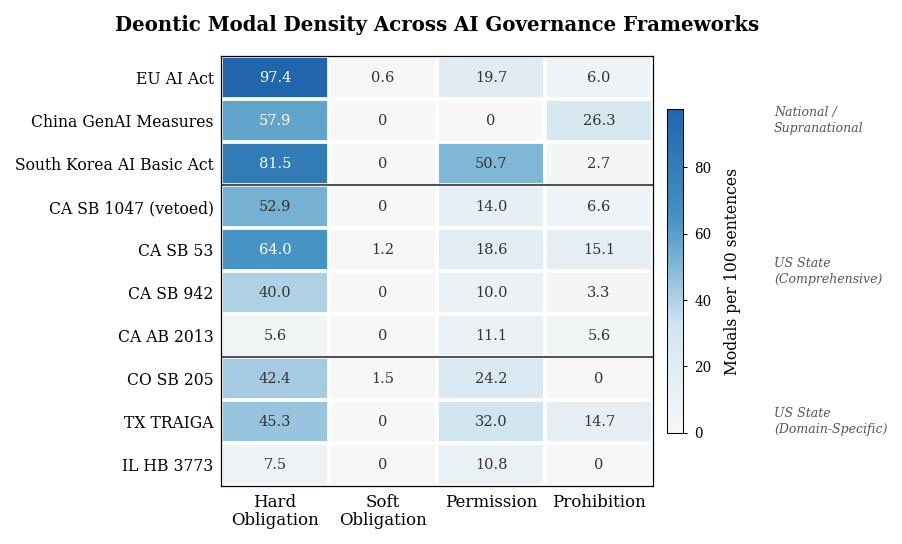

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig1_deontic_density_heatmap.pdf


In [ ]:
# ── Cell 3: Figure 1 — Deontic Modal Density Heatmap ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,       # editable text in PDF
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

fig1, ax1 = plt.subplots(figsize=(5.5, 3.5), dpi=150)

data = density_df.values
ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]

# Custom colormap: white → steel blue (smooth 4-stop)
cmap = LinearSegmentedColormap.from_list(
    "density", ["#f7f7f7", "#d1e5f0", "#4393c3", "#2166ac"], N=256
)

im = ax1.imshow(data, cmap=cmap, aspect="auto", interpolation="nearest")

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        color = "white" if val > (data.max() * 0.55) else "#333333"
        text = f"{val:.1f}" if val >= 0.1 else "0"
        ax1.text(j, i, text, ha="center", va="center",
                 fontsize=7, color=color, fontweight="medium")

# Axis labels
ax1.set_xticks(range(len(CAT_LABELS)))
ax1.set_xticklabels(CAT_LABELS, ha="center", linespacing=1.1)
ax1.set_yticks(range(len(ylabels)))
ax1.set_yticklabels(ylabels, fontsize=7.5)

# Cell-separating gridlines
ax1.set_xticks(np.arange(-0.5, len(CAT_LABELS), 1), minor=True)
ax1.set_yticks(np.arange(-0.5, len(ylabels), 1), minor=True)
ax1.grid(which="minor", color="white", linewidth=1.8)
ax1.tick_params(which="minor", bottom=False, left=False)
ax1.tick_params(which="major", length=0)  # hide major tick marks

# Colorbar — tightly placed
cbar = fig1.colorbar(im, ax=ax1, fraction=0.035, pad=0.03, shrink=0.80)
cbar.set_label("Modals per 100 sentences", fontsize=7.5, labelpad=6)
cbar.ax.tick_params(labelsize=6.5, length=2, width=0.5)
cbar.outline.set_linewidth(0.5)

# Jurisdiction grouping lines
for y_pos in [2.5, 6.5]:
    ax1.axhline(y=y_pos, color="#555555", linewidth=1.0, linestyle="-")

# Jurisdiction bracket labels (right side, outside plot area)
bracket_props = dict(fontsize=6, color="#555555", ha="left", va="center",
                     fontstyle="italic", linespacing=1.3)

# Use axes coordinates so labels sit outside the heatmap consistently
trans = ax1.get_yaxis_transform()
ax1.text(1.28, 1.0, "National /\nSupranational", transform=trans, **bracket_props)
ax1.text(1.28, 4.5, "US State\n(Comprehensive)", transform=trans, **bracket_props)
ax1.text(1.28, 8.0, "US State\n(Domain-Specific)", transform=trans, **bracket_props)

ax1.set_title("Deontic Modal Density Across AI Governance Frameworks",
              pad=12, fontweight="bold", fontsize=9.5)

fig1.subplots_adjust(left=0.22, right=0.78, top=0.90, bottom=0.08)
fig1.savefig(FIGURE_DIR / "fig1_deontic_density_heatmap.pdf", dpi=1200,
             bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig1_deontic_density_heatmap.pdf'}")

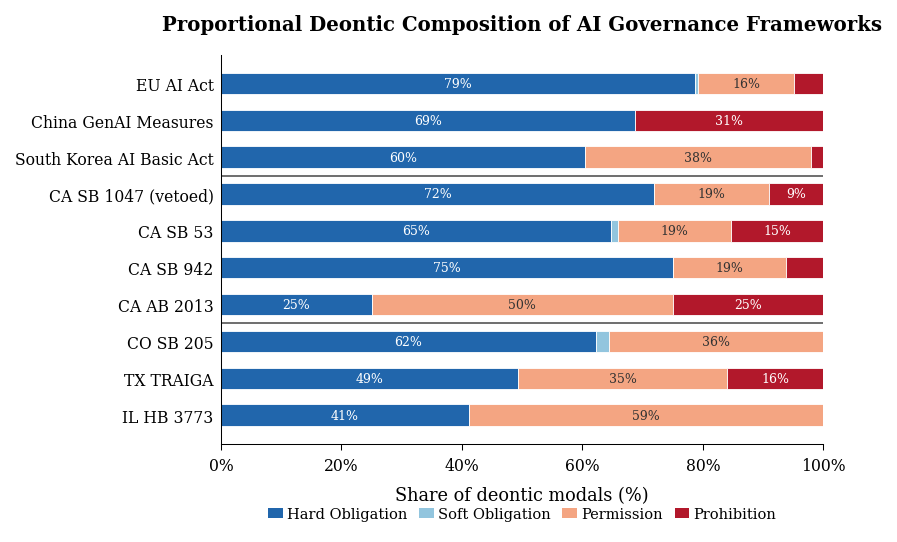

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig2_deontic_composition_stacked.pdf


In [ ]:
# ── Cell 4: Figure 2 — Proportional Deontic Composition ──

fig2, ax2 = plt.subplots(figsize=(5.5, 3.5), dpi=150)

ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]
y_pos = np.arange(len(LAW_ORDER))

# Stacked horizontal bars
left = np.zeros(len(LAW_ORDER))
for cat in CATEGORIES:
    vals = proportion_pct[cat].values
    ax2.barh(y_pos, vals, left=left, height=0.58,
             color=CAT_COLORS[cat], edgecolor="white",
             linewidth=0.4)
    left += vals

# Annotate segments wider than 8%
for cat in CATEGORIES:
    vals = proportion_pct[cat].values
    cumulative = proportion_pct[CATEGORIES[:CATEGORIES.index(cat)]].sum(axis=1).values
    for i, (v, c) in enumerate(zip(vals, cumulative)):
        if v > 8:
            x_center = c + v / 2
            color = "white" if cat in ["HARD_OBLIGATION", "PROHIBITION"] else "#333333"
            ax2.text(x_center, i, f"{v:.0f}%", ha="center", va="center",
                     fontsize=6, color=color, fontweight="medium")

ax2.set_yticks(y_pos)
ax2.set_yticklabels(ylabels, fontsize=7.5)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Share of deontic modals (%)", fontsize=8.5, labelpad=6)
ax2.invert_yaxis()

# X-axis
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax2.tick_params(axis="x", labelsize=7.5, length=3, width=0.5)
ax2.tick_params(axis="y", length=0)  # no y tick marks

# Jurisdiction grouping lines
for y_pos_line in [2.5, 6.5]:
    ax2.axhline(y=y_pos_line, color="#555555", linewidth=0.8, linestyle="-")

# Spines
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(0.5)
ax2.spines["bottom"].set_linewidth(0.5)

# Legend — properly spaced below
legend_labels = ["Hard Obligation", "Soft Obligation", "Permission", "Prohibition"]
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=CAT_COLORS[cat],
           edgecolor="none") for cat in CATEGORIES]
leg = ax2.legend(handles, legend_labels, loc="upper center",
                 bbox_to_anchor=(0.5, -0.13), ncol=4, fontsize=7,
                 frameon=False, handlelength=1.0, handletextpad=0.3,
                 columnspacing=0.8)

ax2.set_title("Proportional Deontic Composition of AI Governance Frameworks",
              pad=12, fontweight="bold", fontsize=9.5)

fig2.subplots_adjust(left=0.22, right=0.95, top=0.90, bottom=0.16)
fig2.savefig(FIGURE_DIR / "fig2_deontic_composition_stacked.pdf", dpi=1200,
             bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig2_deontic_composition_stacked.pdf'}")

In [ ]:
# ── Cell 5: Numerical summary for paper text ──

print("\n" + "=" * 70)
print("KEY STATISTICS FOR PAPER TEXT")
print("=" * 70)

for law_id in LAW_ORDER:
    r = results[law_id]
    s = r["stats"]
    total = s["total_sentences"]
    oblig = s["obligation_sentences"]
    d = s["deontic_counts"]
    total_deontic = sum(d.values())

    hard_pct = (d.get("HARD_OBLIGATION", 0) / total_deontic * 100) if total_deontic > 0 else 0
    proh_pct = (d.get("PROHIBITION", 0) / total_deontic * 100) if total_deontic > 0 else 0
    perm_pct = (d.get("PERMISSION", 0) / total_deontic * 100) if total_deontic > 0 else 0

    print(f"\n{LAW_LABELS[law_id]}:")
    print(f"  {total} sentences, {oblig} obligation ({oblig/total*100:.1f}%)")
    print(f"  Deontic total: {total_deontic} | "
          f"Hard: {hard_pct:.1f}% | Prohibition: {proh_pct:.1f}% | "
          f"Permission: {perm_pct:.1f}%")
    print(f"  Density: {total_deontic/total*100:.1f} modals per 100 sentences")


KEY STATISTICS FOR PAPER TEXT

EU AI Act:
  833 sentences, 710 obligation (85.2%)
  Deontic total: 1030 | Hard: 78.7% | Prohibition: 4.9% | Permission: 15.9%
  Density: 123.6 modals per 100 sentences

China GenAI Measures:
  38 sentences, 16 obligation (42.1%)
  Deontic total: 32 | Hard: 68.8% | Prohibition: 31.2% | Permission: 0.0%
  Density: 84.2 modals per 100 sentences

South Korea AI Basic Act:
  146 sentences, 102 obligation (69.9%)
  Deontic total: 197 | Hard: 60.4% | Prohibition: 2.0% | Permission: 37.6%
  Density: 134.9 modals per 100 sentences

CA SB 1047 (vetoed):
  121 sentences, 56 obligation (46.3%)
  Deontic total: 89 | Hard: 71.9% | Prohibition: 9.0% | Permission: 19.1%
  Density: 73.6 modals per 100 sentences

CA SB 53:
  86 sentences, 54 obligation (62.8%)
  Deontic total: 85 | Hard: 64.7% | Prohibition: 15.3% | Permission: 18.8%
  Density: 98.8 modals per 100 sentences

CA SB 942:
  30 sentences, 13 obligation (43.3%)
  Deontic total: 16 | Hard: 75.0% | Prohibition: